# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

#  Data Wrangling

In [2]:
# LOAD KETIGA DATASET ASLI

df_sintetis = pd.read_csv("RawData/Sintetis_Data.csv")
df_gofood_raw = pd.read_csv("RawData/gofood_food_overviews.csv")
df_tokped_raw = pd.read_csv("RawData/produk_tokopedia.csv")


# WRANGLING TOKOPEDIA (Ambil 10.000 Data)

# Bersihin yang kosong dan harga ga masuk akal dulu
df_tokped = df_tokped_raw.dropna(subset=['Nama Produk', 'Harga (IDR)'])
df_tokped = df_tokped[df_tokped['Harga (IDR)'] < 5000000]
df_tokped_sample = df_tokped.sample(n=10000, random_state=42).copy()

def ngetik_tokped(teks):
    # Split teks panjang, ambil 3 sampai 4 kata 
    kata = str(teks).split()[:random.randint(3, 4)]
    nama_barang = " ".join(kata)
    
    # Tambahin awalan natural
    awalan = random.choice(["Beli ", "Checkout ", "Nyicil ", "Order ", ""])
    hasil = awalan + nama_barang
    
    return hasil.lower() if random.random() < 0.4 else hasil

# Bikin field 1 pintu: deskripsi_transaksi
df_tokped_sample['deskripsi_transaksi'] = df_tokped_sample['Nama Produk'].apply(ngetik_tokped)
df_tokped_sample['kategori'] = "Belanja"
df_tokped_sample['nominal'] = df_tokped_sample['Harga (IDR)'].astype(int)
df_tokped_sample['tipe_transaksi'] = "Pengeluaran"

# Hapus kolom asli biar ga dobel
df_tokped_sample.drop(columns=['Nama Produk', 'Harga (IDR)'], inplace=True)



# WRANGLING GOFOOD (Ambil 5.000 Data)
df_gofood = df_gofood_raw.dropna(subset=['orderItem'])
df_gofood_sample = df_gofood.sample(n=5000, random_state=42).copy()

def ngetik_gofood(teks):
    # Split berdasarkan koma (karena pesanan gofood sering gabung minuman/makanan ekstra)
    item_utama = str(teks).split(',')[0].strip()
    # Split lagi, ambil maksimal 3 kata pertama 
    kata = item_utama.split()[:random.randint(2, 3)]
    nama_makanan = " ".join(kata)
    
    # Tambahin awalan natural
    awalan = random.choice(["Gofood ", "Pesen ", "Grabfood ", "Beli ", "Jajan ", ""])
    hasil = awalan + nama_makanan
    
    return hasil.lower() if random.random() < 0.4 else hasil

# Bikin field setara menjadi deskripsi_transaksi
df_gofood_sample['deskripsi_transaksi'] = df_gofood_sample['orderItem'].apply(ngetik_gofood)
df_gofood_sample['kategori'] = "Makanan"
df_gofood_sample['tipe_transaksi'] = "Pengeluaran"
# Gofood ga punya kolom harga, kita generate acak sesuai harga makanan
df_gofood_sample['nominal'] = [random.randint(15, 150) * 1000 for _ in range(5000)] 

# Hapus kolom asli
df_gofood_sample.drop(columns=['orderItem'], inplace=True)



# GABUNGKAN SEMUANYA JADI  Data-pure
# menggunakan concat untuk mengabung semua
df_master = pd.concat([df_sintetis, df_tokped_sample, df_gofood_sample], ignore_index=True)

# Acak urutan baris biar nyampur rata
df_master = df_master.sample(frac=1).reset_index(drop=True)

# Simpan ke CSV
df_master.to_csv("Data-pure.csv", index=False)

print("WRANGLING SUKSES!")
print(f"Total Baris: {len(df_master)} data")
print("\nPreview Kolom Deskripsi Transaksi (Super Natural):")
print(df_master[['deskripsi_transaksi', 'kategori', 'nominal']].sample(15))

WRANGLING SUKSES!
Total Baris: 30468 data

Preview Kolom Deskripsi Transaksi (Super Natural):
                          deskripsi_transaksi        kategori    nominal
3250               nyicil l] kihiko body         Belanja    14900.0
6856                             uang air kos  Tempat Tinggal -1795000.0
22468          nyicil sepeda lipat 16 pacific         Belanja  1924000.0
13346          nyicil rumahbully | smoke beef         Belanja    49999.0
17567                [NEW LAUNCHING] Mamafuji         Belanja    63999.0
8669                   Checkout Kursi Lipat /         Belanja   338999.0
4313                                  Case HP         Belanja  1316000.0
13983                    pesen hawaii regular         Makanan   113000.0
9110                         pesen bakso lava         Makanan    45000.0
27882                     beli nasi ayam bali         Makanan   109000.0
9984                        Gofood Puyung Hai         Makanan   124000.0
19483  Beli MOODmatcher Lipstik Ori

# ASSESING DATA

In [3]:
# MEngecek keseluruhan data kotor
# Load data kotor
df = pd.read_csv("Data-pure.csv")

print("=== 1. CEK INFO DASAR ===")
df.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df.duplicated().sum())

print("\n=== 4. CEK OUTLIER NOMINAL ===")
print(df['nominal'].describe().apply(lambda x: format(x, 'f')))


=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30468 entries, 0 to 30467
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              15468 non-null  object 
 1   jam                  15468 non-null  object 
 2   deskripsi_transaksi  30468 non-null  object 
 3   kategori             27158 non-null  object 
 4   nominal              28172 non-null  float64
 5   tipe_transaksi       30468 non-null  object 
 6   metode_pembayaran    15468 non-null  object 
 7   lokasi_merchant      9973 non-null   object 
 8   status_transaksi     15468 non-null  object 
 9   device_os            15468 non-null  object 
 10  catatan_user         2330 non-null   object 
 11  Nama Toko            9984 non-null   object 
 12  Lokasi Toko          9955 non-null   object 
 13  Terjual              9920 non-null   object 
 14  Jumlah Ulasan        9532 non-null   object 
 15  Rating    

In [4]:
df.head(10)

,tanggal,jam,deskripsi_transaksi,kategori,nominal,tipe_transaksi,metode_pembayaran,lokasi_merchant,status_transaksi,device_os,...,id,review,rating,createdAt,lastComment,qtyItem,orderedAt,tagsData,replayComment,timeReplayComment
0,02/12/2023,22:46,langganan chatgpt,Hiburan,108000.0,Pengeluaran,Mandiri,Tangerang,Berhasil,Windows Web,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,beli dog & cat raw,Belanja,45000.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,beli formula tooth brush,Belanja,13550.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-03-21,13:40,Indodax,NaN,4624000.0,Pengeluaran,BCA Virtual Account,NaN,Berhasil,iOS 16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,order deli tas laptop sleeve,Belanja,54000.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Order ZXID SALE -,Belanja,79000.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2023-12-16,17:11,UANG SAMPAH KOS,NaN,NaN,Pengeluaran,qris,Online,Berhasil,Windows Web,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,jajan nasi daging rendang,Makanan,71000.0,Pengeluaran,NaN,NaN,NaN,NaN,...,151bc131-1196-4ec7-b923-225ef919d401,ini rendangnya sedikit asin,4.0,2023-11-14T10:48:59.061033+07:00,NaN,1.0,2023-10-18T03:05:34.360023Z,CANNED_RESPONSE_TASTE,NaN,NaN
8,NaN,NaN,Pesen Soto Ayam,Makanan,95000.0,Pengeluaran,NaN,NaN,NaN,NaN,...,4380d11d-f7ca-4492-bd59-f94f6fe7c098,Devi Dental Yogyakarta 0817201281/0818201281/0...,5.0,2020-07-14T08:59:51.155+07:00,NaN,3.0,2020-07-13T01:11:30.835231Z,CANNED_RESPONSE_FRESHNESS CANNED_RESPONSE_TAST...,NaN,NaN
9,NaN,NaN,Jual Ikat pinggang,Belanja,144900.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\user\AppData\Local\Temp\ipykernel_12684\760276003.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_top28.values, y=missing_top28.index, palette='Reds_r', ax=ax2)
C:\Users\user\AppData\Local\Temp\ipykernel_12684\760276003.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kategori_counts.values, y=kategori_counts.index.astype(str), palette='viridis', ax=ax3)


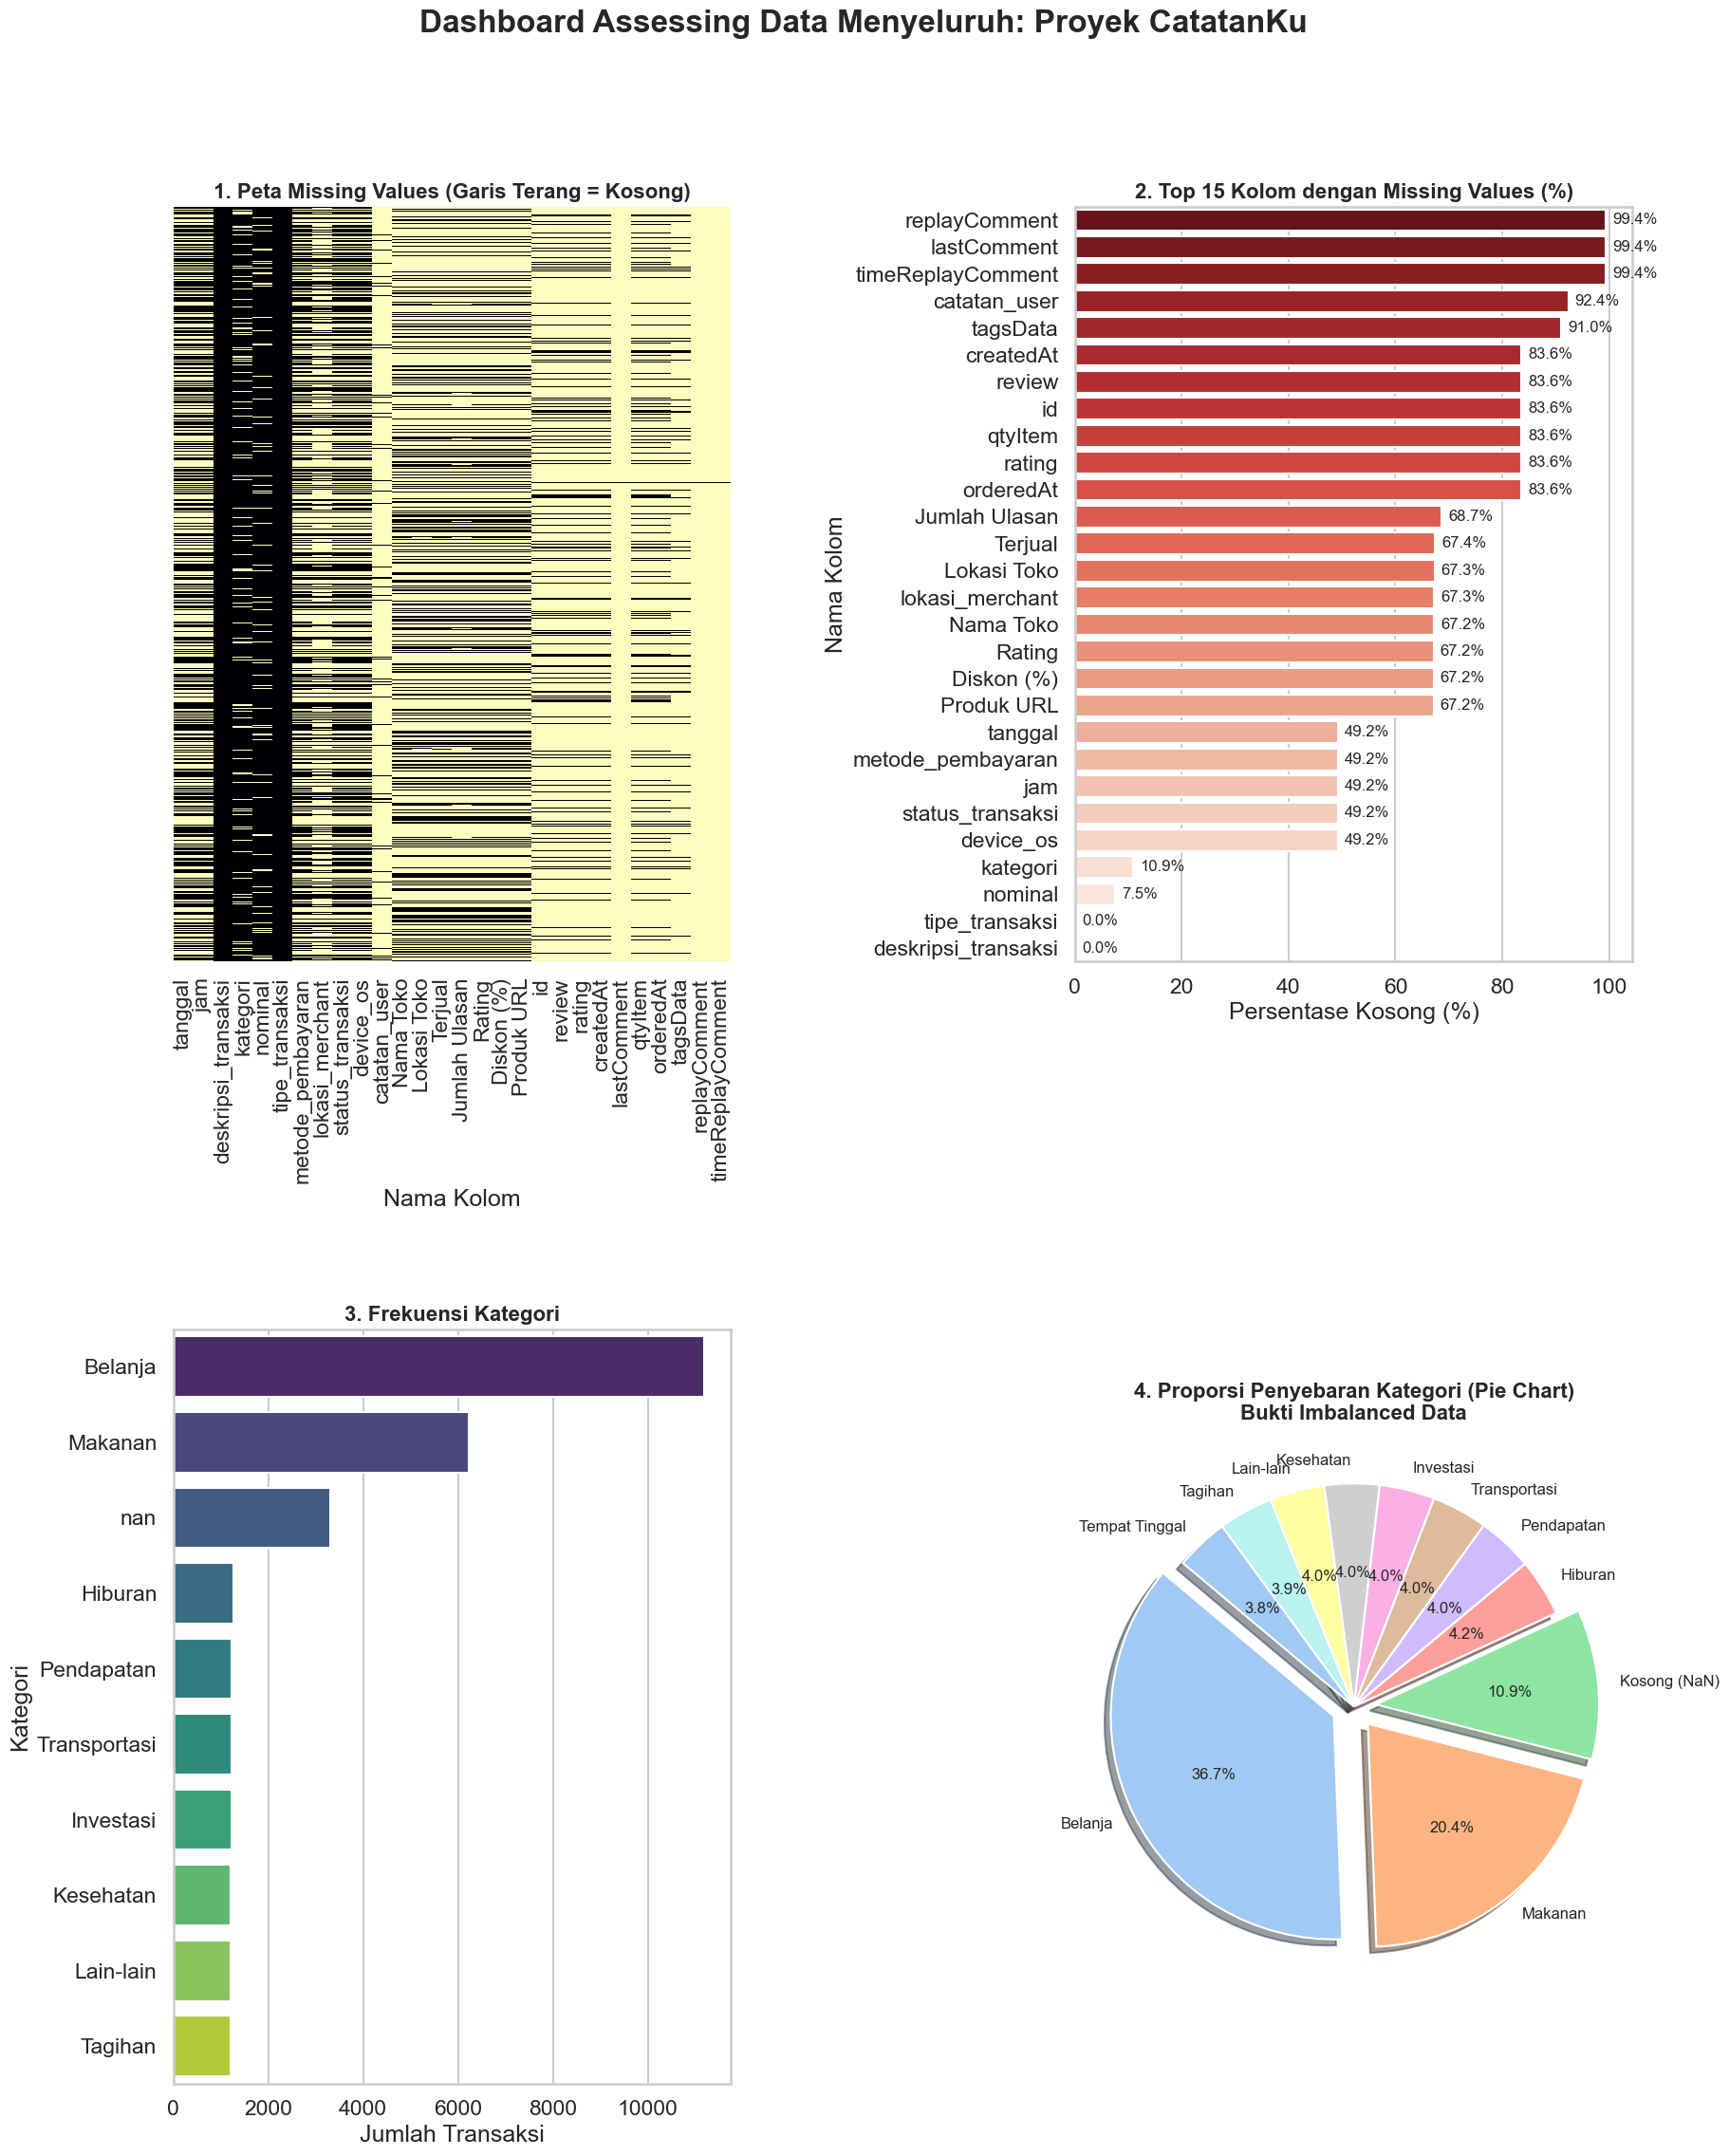

<Figure size 640x480 with 0 Axes>


INTERPRETASI KESELURUHAN (UNTUK LAPORAN ANALISIS):
Berdasarkan Dashboard Assessing Data di atas, terdapat 4 temuan kritikal pada dataset mentah:



In [5]:
# Set tema visualisasi
sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv("Data-pure.csv")


fig = plt.figure(figsize=(20, 24))
fig.suptitle('Dashboard Assessing Data Menyeluruh: Proyek CatatanKu', fontsize=24, fontweight='bold', y=0.98)


# Peta Persebaran Missing Values (Heatmap)
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False, ax=ax1)
ax1.set_title('1. Peta Missing Values (Garis Terang = Kosong)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Nama Kolom')

# Persentase Data Kosong (Bar Chart)
ax2 = plt.subplot(2, 2, 2)
missing_perc = (df.isnull().sum() / len(df)) * 100
missing_top28 = missing_perc.sort_values(ascending=False).head(28)

sns.barplot(x=missing_top28.values, y=missing_top28.index, palette='Reds_r', ax=ax2)
ax2.set_title('2. Top 15 Kolom dengan Missing Values (%)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Persentase Kosong (%)')
ax2.set_ylabel('Nama Kolom')

# Tambahin teks persentase di ujung bar
for p in ax2.patches:
        ax2.annotate(f"{p.get_width():.1f}%", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=12)


# Mendeteksi Kategori Kosong

ax3 = plt.subplot(2, 2, 3)
kategori_counts = df['kategori'].value_counts(dropna=False).head(10) 
sns.barplot(x=kategori_counts.values, y=kategori_counts.index.astype(str), palette='viridis', ax=ax3)
ax3.set_title('3. Frekuensi Kategori', fontsize=16, fontweight='bold')
ax3.set_xlabel('Jumlah Transaksi')
ax3.set_ylabel('Kategori')

ax4 = plt.subplot(2, 2, 4)
# Hitung data buat pie chart 
kategori_pie_counts = df['kategori'].fillna('Kosong (NaN)').value_counts()
explode = [0.1 if i < 3 else 0 for i in range(len(kategori_pie_counts))]
colors = sns.color_palette('pastel')[0:len(kategori_pie_counts)]
# Masukin pie chart ke dalam ax4
ax4.pie(kategori_pie_counts, 
        labels=kategori_pie_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode, 
        shadow=True,
        textprops={'fontsize': 12})
ax4.set_title('4. Proporsi Penyebaran Kategori (Pie Chart)\nBukti Imbalanced Data', fontsize=16, fontweight='bold')

plt.tight_layout(pad=4.0)
plt.show()

plt.tight_layout(pad=4.0)
plt.show()

print("""
=========================================================
INTERPRETASI KESELURUHAN (UNTUK LAPORAN ANALISIS):
=========================================================
Berdasarkan Dashboard Assessing Data di atas, terdapat 4 temuan kritikal pada dataset mentah:
""")

# Cleaning Data

In [6]:
# Ekstraksi Tanggal Bawaan Sistem (GoFood)

# Memastikan kolom 'tanggal' berformat string/object biar gampang ditimpa
df['tanggal'] = df['tanggal'].astype(str).replace('nan', np.nan)

# Ekstrak dari createdAt dan masukkan ke tanggal
if 'createdAt' in df.columns:
    # Ubah format createdAt jadi YYYY-MM-DD
    tanggal_gofood = pd.to_datetime(df['createdAt'], errors='coerce').dt.strftime('%Y-%m-%d')
    
    # Tambal baris 'tanggal' yang kosong pakai data dari 'createdAt'
    df['tanggal'] = np.where(df['tanggal'].isnull(), tanggal_gofood, df['tanggal'])
    
    print("Berhasil! Data 'createdAt' sudah dipindahkan ke kolom 'tanggal'.")
else:
    print("Kolom 'createdAt' tidak ditemukan di dataset.")

print(f"Sisa baris dengan tanggal kosong saat ini: {df['tanggal'].isnull().sum()} baris")

Berhasil! Data 'createdAt' sudah dipindahkan ke kolom 'tanggal'.
Sisa baris dengan tanggal kosong saat ini: 10001 baris


In [7]:
# FEATURE SELECTION (Membuang Kolom Tidak Terpakai)

# Definisikan kolom yang ingin di ambil
kolom_target = [
    'tanggal', 
    'deskripsi_transaksi', 
    'kategori', 
    'nominal', 
    'tipe_transaksi', 
]

# membuat dataframe baru
df_selected = df[kolom_target].copy()

print("Pembuatan Dataframe baru berhasil")
print(f"Bentuk data sekarang: {df_selected.shape[0]} baris & {df_selected.shape[1]} kolom\n")

# Tampilkan 5 data teratas untuk preview
print("\n=== PREVIEW 5 DATA TERATAS ===")
display(df_selected.head())

Pembuatan Dataframe baru berhasil
Bentuk data sekarang: 30468 baris & 5 kolom


=== PREVIEW 5 DATA TERATAS ===


,tanggal,deskripsi_transaksi,kategori,nominal,tipe_transaksi
0,02/12/2023,langganan chatgpt,Hiburan,108000.0,Pengeluaran
1,NaN,beli dog & cat raw,Belanja,45000.0,Pengeluaran
2,NaN,beli formula tooth brush,Belanja,13550.0,Pengeluaran
3,2024-03-21,Indodax,NaN,4624000.0,Pengeluaran
4,NaN,order deli tas laptop sleeve,Belanja,54000.0,Pengeluaran


In [8]:
# Standarisasi Teks dan Nominal
# Bikin deskripsi jadi lowercase semua biar enak dibaca NLP
df_selected['deskripsi_transaksi'] = df_selected['deskripsi_transaksi'].astype(str).str.lower()
# Pastikan nominalnya positif semua (absolute value)
df_selected['nominal'] = df_selected['nominal'].abs()

df_selected.head(10)

,tanggal,deskripsi_transaksi,kategori,nominal,tipe_transaksi
0,02/12/2023,langganan chatgpt,Hiburan,108000.0,Pengeluaran
1,NaN,beli dog & cat raw,Belanja,45000.0,Pengeluaran
2,NaN,beli formula tooth brush,Belanja,13550.0,Pengeluaran
3,2024-03-21,indodax,NaN,4624000.0,Pengeluaran
4,NaN,order deli tas laptop sleeve,Belanja,54000.0,Pengeluaran
5,NaN,order zxid sale -,Belanja,79000.0,Pengeluaran
6,2023-12-16,uang sampah kos,NaN,NaN,Pengeluaran
7,2023-11-14,jajan nasi daging rendang,Makanan,71000.0,Pengeluaran
8,2020-07-14,pesen soto ayam,Makanan,95000.0,Pengeluaran
9,NaN,jual ikat pinggang,Belanja,144900.0,Pengeluaran


In [9]:
# Mengecek kembali data

print("=== 1. CEK INFO DASAR ===")
df_selected.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df_selected.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df_selected.duplicated().sum())

print("\4. CEK STATISTIK DATA")
print(df_selected.describe())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30468 entries, 0 to 30467
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              20467 non-null  object 
 1   deskripsi_transaksi  30468 non-null  object 
 2   kategori             27158 non-null  object 
 3   nominal              28172 non-null  float64
 4   tipe_transaksi       30468 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1.2+ MB

=== 2. CEK DATA KOSONG (Missing Values) ===
tanggal                10001
deskripsi_transaksi        0
kategori                3310
nominal                 2296
tipe_transaksi             0
dtype: int64

=== 3. CEK DATA DUPLIKAT ===
Jumlah Duplikat: 522
. CEK STATISTIK DATA
            nominal
count  2.817200e+04
mean   1.089486e+07
std    1.915494e+08
min    0.000000e+00
25%    6.500000e+04
50%    1.490000e+05
75%    4.900000e+05
max    9.026000e+09


In [10]:
# Random Imputation untuk sisa tanggal kosong

df_selected['tanggal'] = pd.to_datetime(df_selected['tanggal'], errors='coerce')
# Bikin rentang waktu 2023-2024
date_pool = pd.date_range(start="2023-01-01", end="2024-12-31")

jumlah_kosong = df_selected['tanggal'].isnull().sum()
print(f"Mengisi {jumlah_kosong} baris kosong (Tokopedia) dengan tanggal acak...")

if jumlah_kosong > 0:
    random_dates = np.random.choice(date_pool, size=jumlah_kosong, replace=True)
    df_selected.loc[df_selected['tanggal'].isnull(), 'tanggal'] = random_dates

# Pastikan format akhir semuanya YYYY-MM-DD
df_selected['tanggal'] = pd.to_datetime(df_selected['tanggal'], errors='coerce').dt.strftime('%Y-%m-%d')

print("Tidak ada lagi tanggal yang bolong di dataset.")
display(df_selected[['tanggal', 'deskripsi_transaksi']].head())

Mengisi 28884 baris kosong (Tokopedia) dengan tanggal acak...
Tidak ada lagi tanggal yang bolong di dataset.


,tanggal,deskripsi_transaksi
0,2023-02-12,langganan chatgpt
1,2023-04-03,beli dog & cat raw
2,2023-10-27,beli formula tooth brush
3,2024-11-06,indodax
4,2024-03-15,order deli tas laptop sleeve


In [11]:
# menghapus data missing pada field kategori dan nominal
baris_awal = len(df_selected)
# menghapus data baris kosong 
df_selected.dropna(subset=['kategori', 'nominal'], inplace=True)
df_selected.reset_index(drop=True, inplace=True)

#Cek jumlah baris setelah di-drop
baris_akhir = len(df_selected)
total_dihapus = baris_awal - baris_akhir

print(f"Total data yang dihapus (karena kosong/invalid): {total_dihapus} baris")
print(f"Sisa baris data yang bersih dan solid: {baris_akhir} baris")

print("\n=== CEK SISA DATA KOSONG SAAT INI ===")
print(df_selected.isnull().sum())

Total data yang dihapus (karena kosong/invalid): 5103 baris
Sisa baris data yang bersih dan solid: 25365 baris

=== CEK SISA DATA KOSONG SAAT INI ===
tanggal                0
deskripsi_transaksi    0
kategori               0
nominal                0
tipe_transaksi         0
dtype: int64


In [12]:
# Mengecek kembali data

print("=== 1. CEK INFO DASAR ===")
df_selected.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df_selected.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df_selected.duplicated().sum())

print("\n4. CEK STATISTIK DATA")
print(df_selected.describe())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25365 entries, 0 to 25364
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              25365 non-null  object 
 1   deskripsi_transaksi  25365 non-null  object 
 2   kategori             25365 non-null  object 
 3   nominal              25365 non-null  float64
 4   tipe_transaksi       25365 non-null  object 
dtypes: float64(1), object(4)
memory usage: 990.9+ KB

=== 2. CEK DATA KOSONG (Missing Values) ===
tanggal                0
deskripsi_transaksi    0
kategori               0
nominal                0
tipe_transaksi         0
dtype: int64

=== 3. CEK DATA DUPLIKAT ===
Jumlah Duplikat: 28

4. CEK STATISTIK DATA
            nominal
count  2.536500e+04
mean   9.575341e+06
std    1.796174e+08
min    0.000000e+00
25%    6.100000e+04
50%    1.380000e+05
75%    4.500000e+05
max    9.026000e+09


In [13]:
# menghapus data duplikat

baris_sebelum = len(df_selected)

# menghitung ada berapa baris yang duplikat 100% (semua kolomnya sama persis)
jumlah_duplikat = df_selected.duplicated().sum()
print(f"Ditemukan {jumlah_duplikat} baris data yang duplikat.")

if jumlah_duplikat > 0:
    # menyimpan baris pertama pada data duplikat
    df_selected.drop_duplicates(keep='first', inplace=True)
    
    # Reset index biar urutan angkanya (0, 1, 2, dst) 
    df_selected.reset_index(drop=True, inplace=True)
    print("Data duplikat berhasil dibasmi!")
else:
    print("Aman! Tidak ditemukan data duplikat.")
    
baris_setelah = len(df_selected)
print(f"\nHASIL AKHIR ")
print(f"Total baris awal: {baris_sebelum}")
print(f"Total baris sekarang: {baris_setelah} baris ")

Ditemukan 28 baris data yang duplikat.
Data duplikat berhasil dibasmi!

HASIL AKHIR 
Total baris awal: 25365
Total baris sekarang: 25337 baris 


In [14]:
# Menangani anomali pada field 'nominal'
df_selected['nominal'] = pd.to_numeric(df_selected['nominal'], errors='coerce').abs()

# Cek baris sebelum filter IQR
baris_sebelum_iqr = len(df_selected)

Q1 = df_selected['nominal'].quantile(0.25)
Q3 = df_selected['nominal'].quantile(0.75)
IQR = Q3 - Q1

# membuat batas atas (Batas bawah nggak terlalu perlu karena udah di-absolut jadi positif semua)
batas_atas = Q3 + 1.5 * IQR

print(f"Statistik Nominal:")
print(f"- Q1 (Kuartil Bawah): Rp {Q1:,.0f}")
print(f"- Q3 (Kuartil Atas): Rp {Q3:,.0f}")
print(f"- Batas Atas Wajar: Rp {batas_atas:,.0f}")

# melakukan eksekusi
df_selected = df_selected[df_selected['nominal'] <= batas_atas]
# mereset index setelah eksekusi
df_selected.reset_index(drop=True, inplace=True)

# hasil
baris_setelah_iqr = len(df_selected)
outlier_dihapus = baris_sebelum_iqr - baris_setelah_iqr
print(f"\nPembersihan Outlier Berhasil!")
print(f"Total data ekstrem (outlier) yang dihapus: {outlier_dihapus} baris")
print(f"Sisa data final saat ini: {baris_setelah_iqr} baris")

Statistik Nominal:
- Q1 (Kuartil Bawah): Rp 60,775
- Q3 (Kuartil Atas): Rp 450,000
- Batas Atas Wajar: Rp 1,033,838

Pembersihan Outlier Berhasil!
Total data ekstrem (outlier) yang dihapus: 3825 baris
Sisa data final saat ini: 21512 baris


In [15]:
# Mengecek kembali data

print("=== 1. CEK INFO DASAR ===")
df_selected.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df_selected.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df_selected.duplicated().sum())

print("\n4. CEK STATISTIK DATA")
print(df_selected.describe())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21512 entries, 0 to 21511
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              21512 non-null  object 
 1   deskripsi_transaksi  21512 non-null  object 
 2   kategori             21512 non-null  object 
 3   nominal              21512 non-null  float64
 4   tipe_transaksi       21512 non-null  object 
dtypes: float64(1), object(4)
memory usage: 840.4+ KB

=== 2. CEK DATA KOSONG (Missing Values) ===
tanggal                0
deskripsi_transaksi    0
kategori               0
nominal                0
tipe_transaksi         0
dtype: int64

=== 3. CEK DATA DUPLIKAT ===
Jumlah Duplikat: 0

4. CEK STATISTIK DATA
            nominal
count  2.151200e+04
mean   1.914424e+05
std    2.144704e+05
min    0.000000e+00
25%    5.100000e+04
50%    1.120000e+05
75%    2.390000e+05
max    1.033000e+06


In [16]:
df_selected.head()

,tanggal,deskripsi_transaksi,kategori,nominal,tipe_transaksi
0,2023-02-12,langganan chatgpt,Hiburan,108000.0,Pengeluaran
1,2023-04-03,beli dog & cat raw,Belanja,45000.0,Pengeluaran
2,2023-10-27,beli formula tooth brush,Belanja,13550.0,Pengeluaran
3,2024-03-15,order deli tas laptop sleeve,Belanja,54000.0,Pengeluaran
4,2024-11-29,order zxid sale -,Belanja,79000.0,Pengeluaran


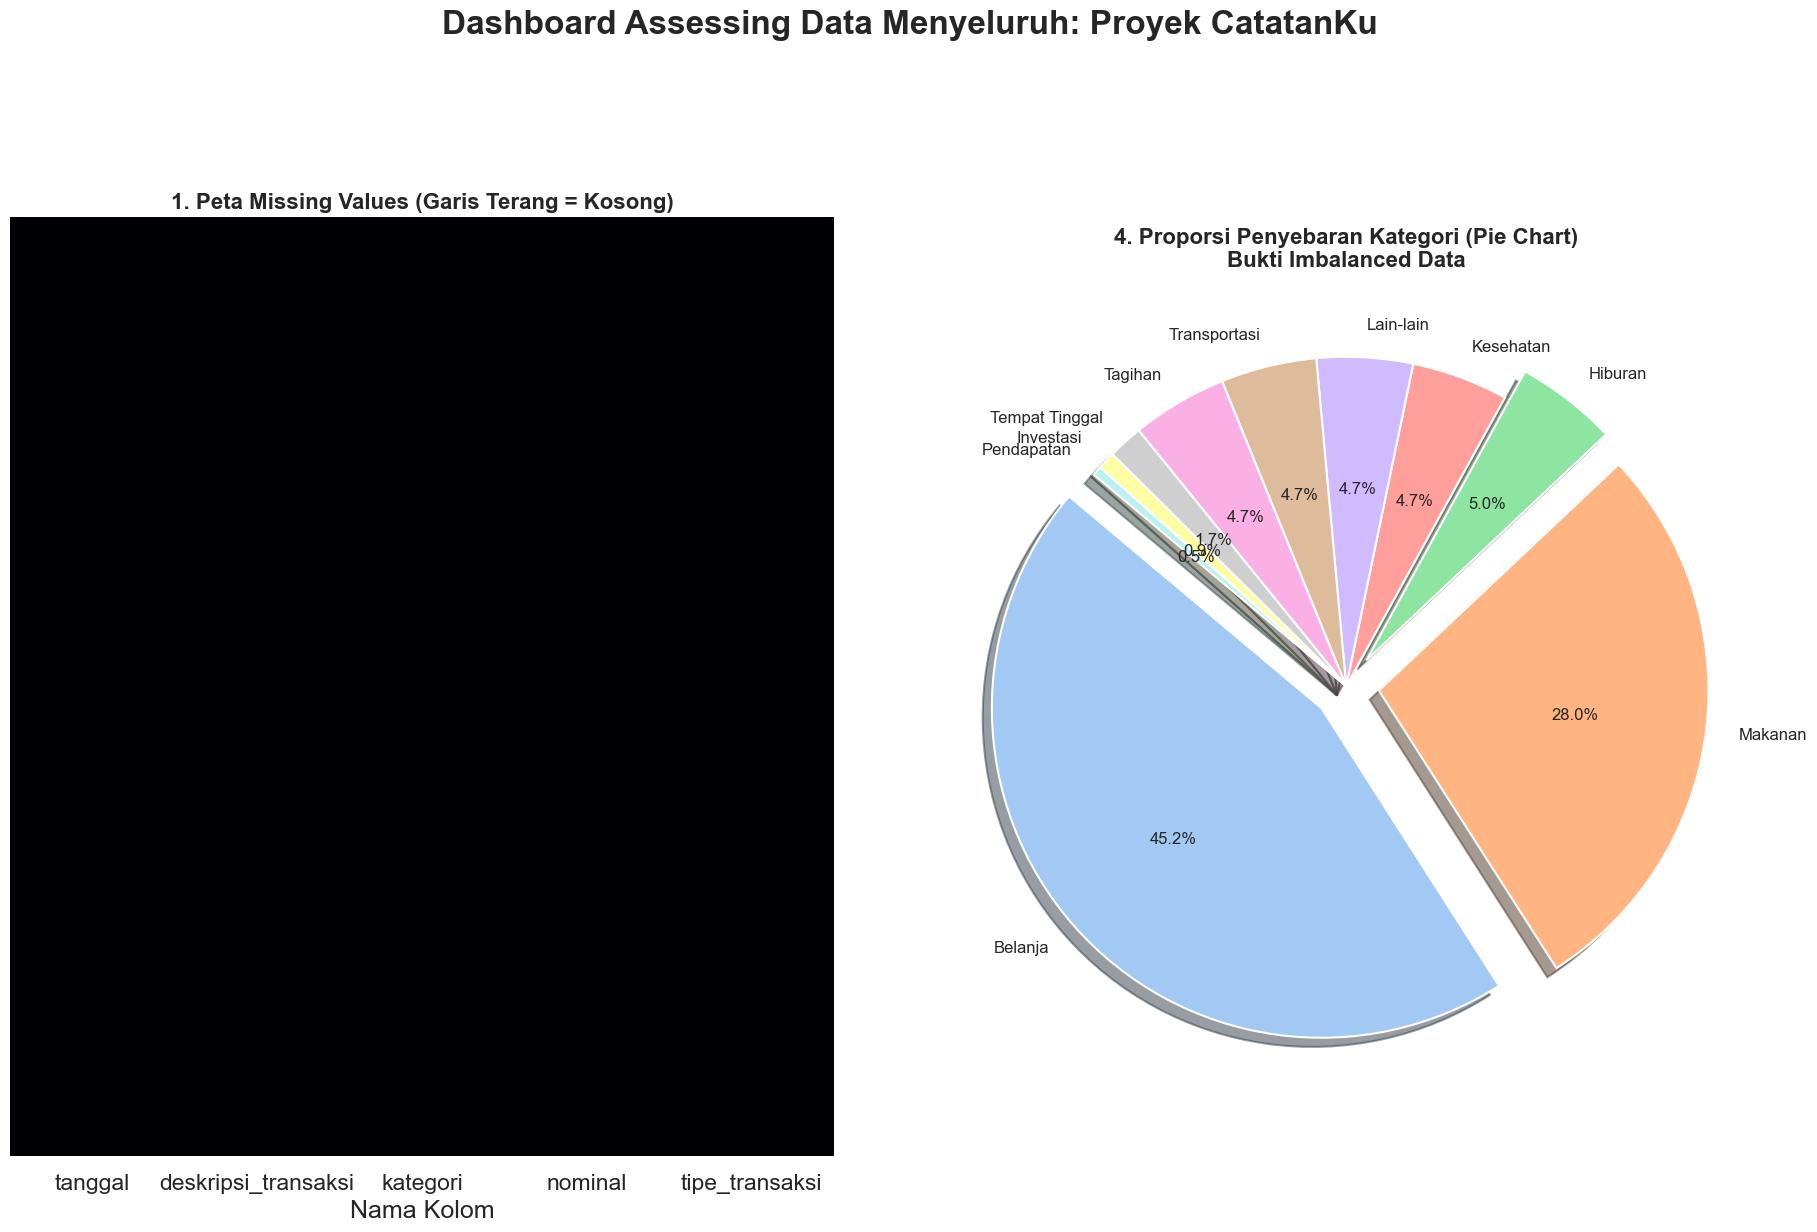

<Figure size 640x480 with 0 Axes>

In [17]:
sns.set_theme(style="whitegrid", context="talk")

df = df_selected


fig = plt.figure(figsize=(20, 24))
fig.suptitle('Dashboard Assessing Data Menyeluruh: Proyek CatatanKu', fontsize=24, fontweight='bold', y=0.98)


# Peta Persebaran Missing Values (Heatmap)
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False, ax=ax1)
ax1.set_title('1. Peta Missing Values (Garis Terang = Kosong)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Nama Kolom')

ax2 = plt.subplot(2, 2, 2)
# Hitung data buat pie chart (ubah NaN jadi teks biar terbaca di chart)
kategori_pie_counts = df['kategori'].fillna('Kosong (NaN)').value_counts()
explode = [0.1 if i < 3 else 0 for i in range(len(kategori_pie_counts))]
colors = sns.color_palette('pastel')[0:len(kategori_pie_counts)]
# Masukin pie chart ke dalam ax4
ax2.pie(kategori_pie_counts, 
        labels=kategori_pie_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode, 
        shadow=True,
        textprops={'fontsize': 12})
ax2.set_title('4. Proporsi Penyebaran Kategori (Pie Chart)\nBukti Imbalanced Data', fontsize=16, fontweight='bold')

plt.tight_layout(pad=4.0)
plt.show()

plt.tight_layout(pad=4.0)
plt.show()


In [18]:
df_selected['tanggal'] = pd.to_datetime(df_selected['tanggal'])

In [19]:
df_selected.to_csv("Data-clean.csv", index=False)

# EDA

In [20]:
df_selected.describe(include='all')

,tanggal,deskripsi_transaksi,kategori,nominal,tipe_transaksi
count,21512,21512,21512,2.151200e+04,21512
unique,NaN,13723,10,NaN,2
top,NaN,photobox,Belanja,NaN,Pengeluaran
freq,NaN,119,9716,NaN,21412
mean,2023-12-29 08:55:34.920044800,NaN,NaN,1.914424e+05,NaN
min,2023-01-01 00:00:00,NaN,NaN,0.000000e+00,NaN
25%,2023-06-29 00:00:00,NaN,NaN,5.100000e+04,NaN
50%,2023-12-27 00:00:00,NaN,NaN,1.120000e+05,NaN
75%,2024-06-30 00:00:00,NaN,NaN,2.390000e+05,NaN
max,2024-12-31 00:00:00,NaN,NaN,1.033000e+06,NaN


In [21]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21512 entries, 0 to 21511
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   tanggal              21512 non-null  datetime64[ns]
 1   deskripsi_transaksi  21512 non-null  object        
 2   kategori             21512 non-null  object        
 3   nominal              21512 non-null  float64       
 4   tipe_transaksi       21512 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 840.4+ KB


In [22]:
df_pengeluaran = df_selected[df_selected['tipe_transaksi'] == 'Pengeluaran']
df_pemasukan = df_selected[df_selected['tipe_transaksi'] == 'Pemasukan']

## Univariate Analysis

In [23]:
print("DISTRIBUSI BERDASARKAN WAKTU")
print("-" * 40)

# Ekstrak tahun dan bulan
df_selected['tahun'] = df_selected['tanggal'].dt.year
df_selected['bulan'] = df_selected['tanggal'].dt.month
df_selected['tahun_bulan'] = df_selected['tanggal'].dt.to_period('M')

print("\nTransaksi per Tahun:")
print(df['tahun'].value_counts().sort_index())
print(f" Range Tanggal :{df['tanggal'].min()} - {df['tanggal'].max()}")

DISTRIBUSI BERDASARKAN WAKTU
----------------------------------------

Transaksi per Tahun:
tahun
2023    10879
2024    10633
Name: count, dtype: int64
 Range Tanggal :2023-01-01 00:00:00 - 2024-12-31 00:00:00


### Tipe Transaksi

DISTRIBUSI TIPE TRANSAKSI
----------------------------------------
tipe_transaksi
Pengeluaran    21412
Pemasukan        100
Name: count, dtype: int64


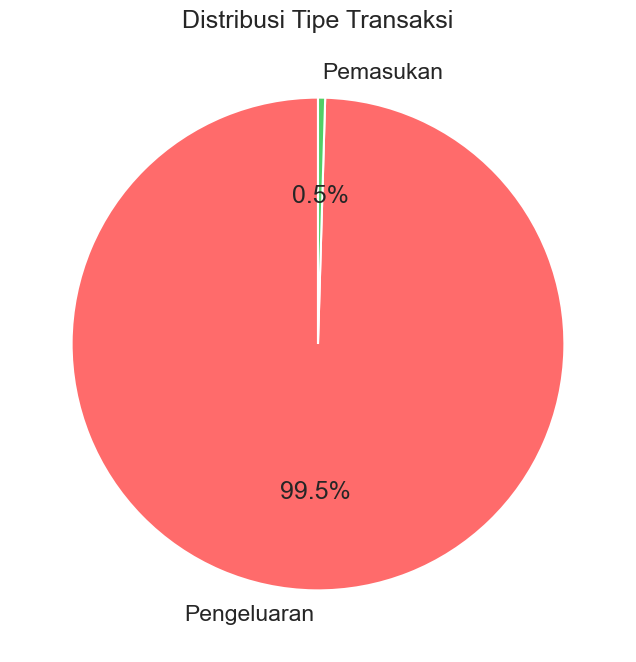

In [24]:
print("DISTRIBUSI TIPE TRANSAKSI")
print("-" * 40)

type_transaction_count = df_selected['tipe_transaksi'].value_counts()
print(type_transaction_count)

percent_expenses = type_transaction_count['Pengeluaran']/len(df)*100
percent_income = type_transaction_count['Pemasukan']/len(df)*100

plt.figure(figsize=(8,8))
plt.pie(type_transaction_count.values, labels=type_transaction_count.index, autopct='%1.1f%%',colors=['#ff6b6b', '#51cf66'],startangle=90)

plt.title('Distribusi Tipe Transaksi')
plt.show()



In [25]:
### Kategori Pengeluaran

In [26]:
print("DISTRIBUSI KATEGORI")
print("-" * 40)

kategori_counts = df_selected['kategori'].value_counts()
kategori_total = df_selected.groupby('kategori')['nominal'].sum().sort_values(ascending=False)
print(kategori_counts)

print("\nFrekuensi per Kategori (Top 10):")
print(kategori_counts.head(10))
print("\nTotal Nominal per Kategori (Top 10):")
print(kategori_total.head(10).apply(lambda x: f"Rp {x:,.0f}"))



DISTRIBUSI KATEGORI
----------------------------------------
kategori
Belanja           9716
Makanan           6018
Hiburan           1070
Kesehatan         1018
Lain-lain         1014
Transportasi      1011
Tagihan           1009
Tempat Tinggal     369
Investasi          187
Pendapatan         100
Name: count, dtype: int64

Frekuensi per Kategori (Top 10):
kategori
Belanja           9716
Makanan           6018
Hiburan           1070
Kesehatan         1018
Lain-lain         1014
Transportasi      1011
Tagihan           1009
Tempat Tinggal     369
Investasi          187
Pendapatan         100
Name: count, dtype: int64

Total Nominal per Kategori (Top 10):
kategori
Belanja           Rp 1,759,852,369
Makanan             Rp 554,432,000
Tagihan             Rp 524,733,000
Hiburan             Rp 273,105,000
Lain-lain           Rp 261,416,000
Kesehatan           Rp 259,754,000
Tempat Tinggal      Rp 193,881,000
Transportasi        Rp 130,266,000
Investasi           Rp 105,724,000
Pendapatan   

### Statistik Deskriptif Nominal

In [27]:
print("STATISTIK DESKRIPTIF NOMINAL")
print("-" * 40)
print("\nSeluruh Transaksi:")
print(df_selected['nominal'].describe().apply(lambda x: f"Rp {x:,.0f}" if pd.notnull(x) else x))

print("\nPengeluaran Saja:")
print(df_pengeluaran['nominal'].describe().apply(lambda x: f"Rp {x:,.0f}" if pd.notnull(x) else x))

print("\nPemasukan Saja:")
print(df_pemasukan['nominal'].describe().apply(lambda x: f"Rp {x:,.0f}" if pd.notnull(x) else x))


STATISTIK DESKRIPTIF NOMINAL
----------------------------------------

Seluruh Transaksi:
count       Rp 21,512
mean       Rp 191,442
std        Rp 214,470
min              Rp 0
25%         Rp 51,000
50%        Rp 112,000
75%        Rp 239,000
max      Rp 1,033,000
Name: nominal, dtype: object

Pengeluaran Saja:
count       Rp 21,412
mean       Rp 189,761
std        Rp 212,601
min              Rp 0
25%         Rp 51,000
50%        Rp 111,000
75%        Rp 236,980
max      Rp 1,033,000
Name: nominal, dtype: object

Pemasukan Saja:
count          Rp 100
mean       Rp 551,450
std        Rp 296,012
min         Rp 52,000
25%        Rp 297,000
50%        Rp 551,000
75%        Rp 820,750
max      Rp 1,032,000
Name: nominal, dtype: object


## Bivariate Analysis

In [28]:
# Bulan Dengan Total Spending Terbanyak
df_exp = df_selected[df_selected['tipe_transaksi'] == 'Pengeluaran'].copy()
df_exp['nama_bulan'] = df_exp['tanggal'].dt.strftime('%b')

# Filter hanya tahun 2023 dan 2024
df_2y = df_exp[df_exp['tahun'].isin([2023, 2024])]

# Hitung total pengeluaran per tahun-bulan
exp_monthly = df_2y.groupby(['tahun', 'bulan'])['nominal'].sum().reset_index()

# Ambil bulan dengan pengeluaran tertinggi
top1 = exp_monthly.loc[exp_monthly['nominal'].idxmax()]

# Ambil 3 bulan dengan pengeluaran tertinggi
top3 = exp_monthly.nlargest(3, 'nominal')

print("="*60)
print("Bulan dengan Total Spending Tertinggi")
print("="*60)

print(f"   Bulan dengan pengeluaran tertinggi: {top1['tahun']}-{int(top1['bulan'])}")
print(f"   Total: Rp {top1['nominal']:,.0f}")

print(f"\n Top 3 Bulan Tertinggi:")
for i, row in top3.iterrows():
    print(f"   {int(row['tahun'])}-{int(row['bulan'])}: Rp {row['nominal']:,.0f}")



Bulan dengan Total Spending Tertinggi
   Bulan dengan pengeluaran tertinggi: 2023.0-3
   Total: Rp 191,399,233

 Top 3 Bulan Tertinggi:
   2023-3: Rp 191,399,233
   2023-6: Rp 186,310,882
   2024-12: Rp 184,170,252


In [29]:

eba = df_exp['tanggal'].max() - timedelta(days=180)
df_6bln = df_exp[df_exp['tanggal'] >= eba].copy()

df_6bln['tipe_hari'] = df_6bln['tanggal'].dt.dayofweek.apply(
    lambda x: 'Akhir Pekan' if x>=5 else 'Hari Kerja'
)

# perbedaan mean nominal relatif ke hari kerja
mean_per_hari = df_6bln.groupby('tipe_hari')['nominal'].mean()
selisih = mean_per_hari.get('Akhir Pekan' , 0) - mean_per_hari.get('Hari Kerja' ,0 )
persen_selisih = abs(selisih / mean_per_hari.get('Hari Kerja', 1) * 100)

#
kategori_hari = df_6bln.groupby(['kategori', 'tipe_hari'])['nominal'].sum().unstack(fill_value=0)
kategori_hari['selisih'] = kategori_hari['Akhir Pekan'] - kategori_hari['Hari Kerja']
top_penyebab = kategori_hari.sort_values('selisih', ascending=False).head(3)


# Cetak Insight
print("\n" + "="*60)
print("Akhir Pekan vs Hari Kerja")
print("="*60)

print(f"\nPERBEDAAN RATA-RATA:")
print(f"   Hari Kerja:   Rp {mean_per_hari.get('Hari Kerja', 0):,.0f}")
print(f"   Akhir Pekan:  Rp {mean_per_hari.get('Akhir Pekan', 0):,.0f}")
print(f"   Selisih:      Rp {selisih:,.0f} ({persen_selisih:.1f}% {'LEBIH BESAR' if selisih > 0 else 'LEBIH KECIL'} di akhir pekan)")

print(f"\nKATEGORI PENYEBAB TERBESAR:")
print(f"   TOP 3 kategori yang membuat akhir pekan lebih boros:")
for i, (kategori, row) in enumerate(top_penyebab.iterrows(), 1):
    selisih_cat = row['selisih']
    if selisih_cat > 0:
        print(f"   {i}. {kategori}: Rp {selisih_cat:,.0f} LEBIH BESAR di akhir pekan")
    else:
        print(f"   {i}. {kategori}: Rp {abs(selisih_cat):,.0f} LEBIH BESAR di hari kerja")


Akhir Pekan vs Hari Kerja

PERBEDAAN RATA-RATA:
   Hari Kerja:   Rp 185,979
   Akhir Pekan:  Rp 185,390
   Selisih:      Rp -589 (0.3% LEBIH KECIL di akhir pekan)

KATEGORI PENYEBAB TERBESAR:
   TOP 3 kategori yang membuat akhir pekan lebih boros:
   1. Investasi: Rp 9,812,000 LEBIH BESAR di hari kerja
   2. Transportasi: Rp 13,479,000 LEBIH BESAR di hari kerja
   3. Lain-lain: Rp 15,017,000 LEBIH BESAR di hari kerja


In [30]:

sta = df_exp['tanggal'].max() - timedelta(days=365)
df_1thn = df_exp[df_exp['tanggal'] >= sta].copy()

outlier_details = []
total_outlier = 0
jumlah_outlier = 0

for periode, group in df_1thn.groupby(df_1thn['tanggal'].dt.to_period('M')):
    mean = group['nominal'].mean()
    std = group['nominal'].std()
    batas_atas = mean + 2 * std
    
    outlier = group[group['nominal'] > batas_atas]
    total_outlier += outlier['nominal'].sum()
    jumlah_outlier += len(outlier)
    
    for _, row in outlier.iterrows():
        outlier_details.append({
            'kategori': row['kategori'],
            'nominal': row['nominal'],
            'deskripsi': row['deskripsi_transaksi']
        })

# Insight 3b: Outlier yang bisa dicegah
outlier_df = pd.DataFrame(outlier_details)
bisa_dicegah = outlier_df[
    (outlier_df['kategori'].isin(['Belanja', 'Makanan'])) & 
    (outlier_df['nominal'] > 500_000)
]
total_bisa_dicegah = bisa_dicegah['nominal'].sum()
persen_bisa_dicegah = (total_bisa_dicegah / total_outlier * 100) if total_outlier > 0 else 0

# Insight 3c: Kategori outlier terbanyak
top_outlier_cat = outlier_df['kategori'].value_counts()

# Cetak Insight
print("\n" + "="*60)
print("Analisis Outlier & Potensi Penghematan")
print("="*60)

print(f"\nTOTAL KERUGIAN DARI OUTLIER:")
print(f"   Total outlier (1 tahun): Rp {total_outlier:,.0f}")
print(f"   Jumlah transaksi outlier: {jumlah_outlier} transaksi")
print(f"   Rata-rata per transaksi outlier: Rp {total_outlier/jumlah_outlier:,.0f}" if jumlah_outlier > 0 else "")

print(f"\nOUTLIER BERDASARKAN KATEGORI:")
print(f"   Top 3 kategori penyumbang outlier:")
for i, (cat, count) in enumerate(top_outlier_cat.head(3).items(), 1):
    total_cat = outlier_df[outlier_df['kategori'] == cat]['nominal'].sum()
    print(f"   {i}. {cat}: {count} transaksi, total Rp {total_cat:,.0f}")

print(f"\nSIMULASI KEBIJAKAN 'TUNGGU 3 HARI':")
print(f"   Definisi: Belanja >Rp500rb di kategori Belanja/Makanan")
print(f"   Total outlier yang BISA DICEGAH: Rp {total_bisa_dicegah:,.0f}")
print(f"   ({persen_bisa_dicegah:.1f}% dari total kerugian outlier)")
print(f"   Jumlah transaksi yang bisa dicegah: {len(bisa_dicegah)}")

print(f"\nINSIGHT 3d - DAFTAR TRANSAKSI PRIORITAS (yang bisa dicegah):")
if len(bisa_dicegah) > 0:
    for i, row in bisa_dicegah.head(5).iterrows():
        print(f"   • {row['kategori']}: Rp {row['nominal']:,.0f} - {row['deskripsi'][:50]}")
else:
    print("   → Tidak ada transaksi yang memenuhi kriteria")


Analisis Outlier & Potensi Penghematan

TOTAL KERUGIAN DARI OUTLIER:
   Total outlier (1 tahun): Rp 568,871,701
   Jumlah transaksi outlier: 696 transaksi
   Rata-rata per transaksi outlier: Rp 817,344

OUTLIER BERDASARKAN KATEGORI:
   Top 3 kategori penyumbang outlier:
   1. Belanja: 389 transaksi, total Rp 318,646,701
   2. Tagihan: 198 transaksi, total Rp 160,173,000
   3. Tempat Tinggal: 67 transaksi, total Rp 54,688,000

SIMULASI KEBIJAKAN 'TUNGGU 3 HARI':
   Definisi: Belanja >Rp500rb di kategori Belanja/Makanan
   Total outlier yang BISA DICEGAH: Rp 318,646,701
   (56.0% dari total kerugian outlier)
   Jumlah transaksi yang bisa dicegah: 389

INSIGHT 3d - DAFTAR TRANSAKSI PRIORITAS (yang bisa dicegah):
   • Belanja: Rp 877,000 - checkout tokopedia
   • Belanja: Rp 791,000 - belanja di alfamidi
   • Belanja: Rp 995,000 - baju thrift
   • Belanja: Rp 760,000 - panci
   • Belanja: Rp 935,000 - checkout shopee


# Visualisasi

## Pertanyaan 1 - Di bulan apa total pengeluaran tertinggi terjadi dalam dua tahun terakhir?

C:\Users\user\AppData\Local\Temp\ipykernel_12684\249512551.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


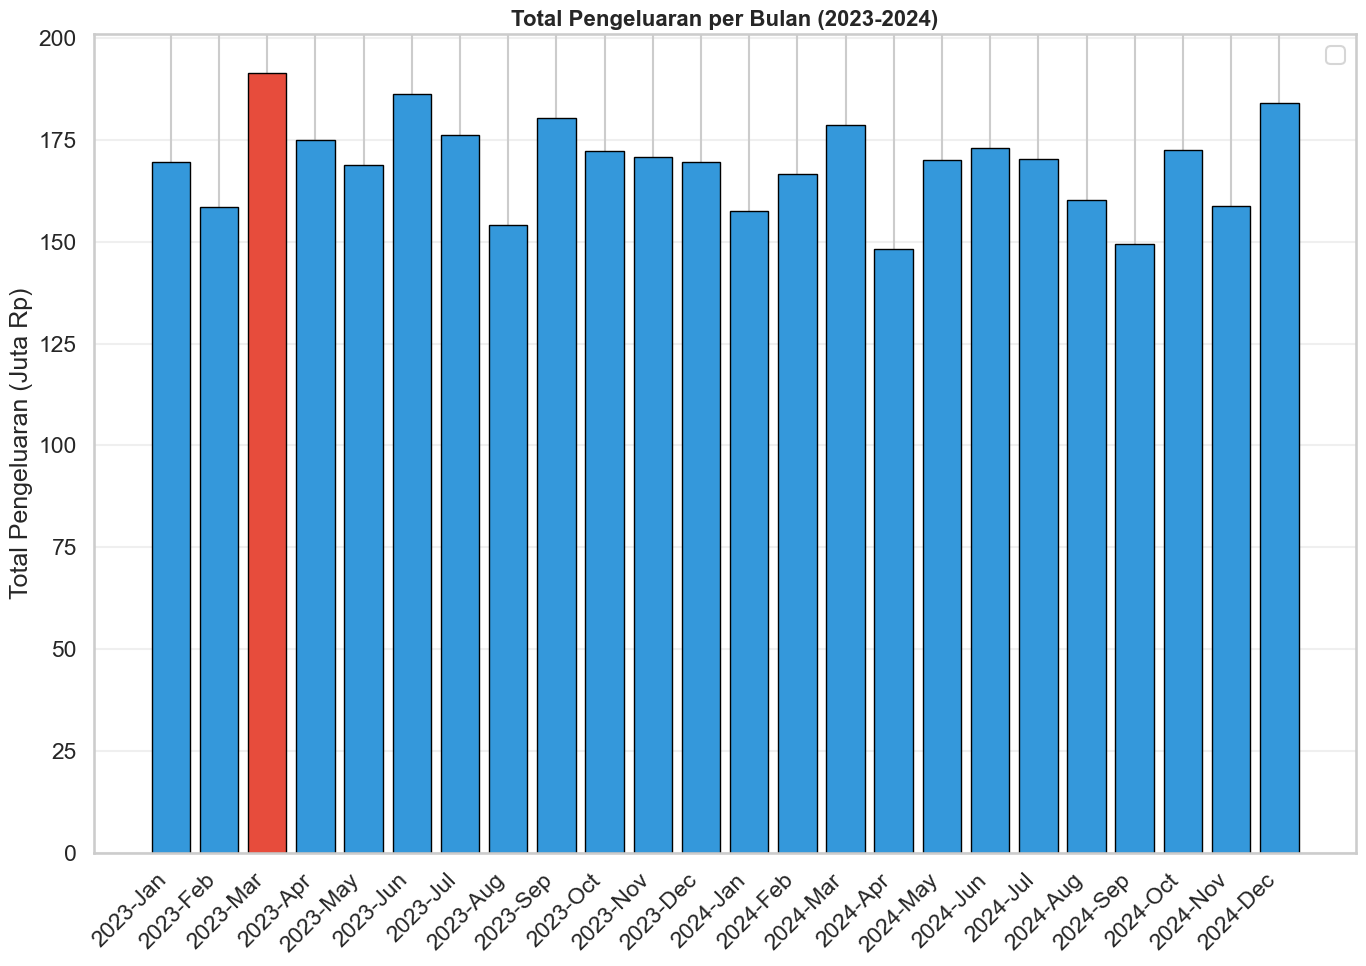

In [31]:
monthly_agg = df_2y.groupby(['tahun' , 'bulan' , 'nama_bulan'])['nominal'].sum().reset_index()
monthly_agg['periode'] = monthly_agg['tahun'].astype(str) + '-' + monthly_agg['nama_bulan']
top_month = monthly_agg.loc[monthly_agg['nominal'].idxmax()]

# Visualisasi
colors =  ['#e74c3c' if row['nominal'] == top_month['nominal'] else '#3498db' 
          for _, row in monthly_agg.iterrows()]

# plot
fig, ax = plt.subplots(figsize=(14,10))
bars = bars = ax.bar(monthly_agg['periode'], monthly_agg['nominal']/1_000_000, color=colors, edgecolor='black', linewidth=1)
ax.set_title('Total Pengeluaran per Bulan (2023-2024)', fontsize=16, fontweight='bold')
ax.set_ylabel('Total Pengeluaran (Juta Rp)')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Pertanyaan 2 - Apa perbedaan rata-rata pengeluaran antara akhir pekan dan hari kerja dalam 6 bulan terakhir, dan kategori apa yang paling signifikan penyebab perbedaan tersebut?

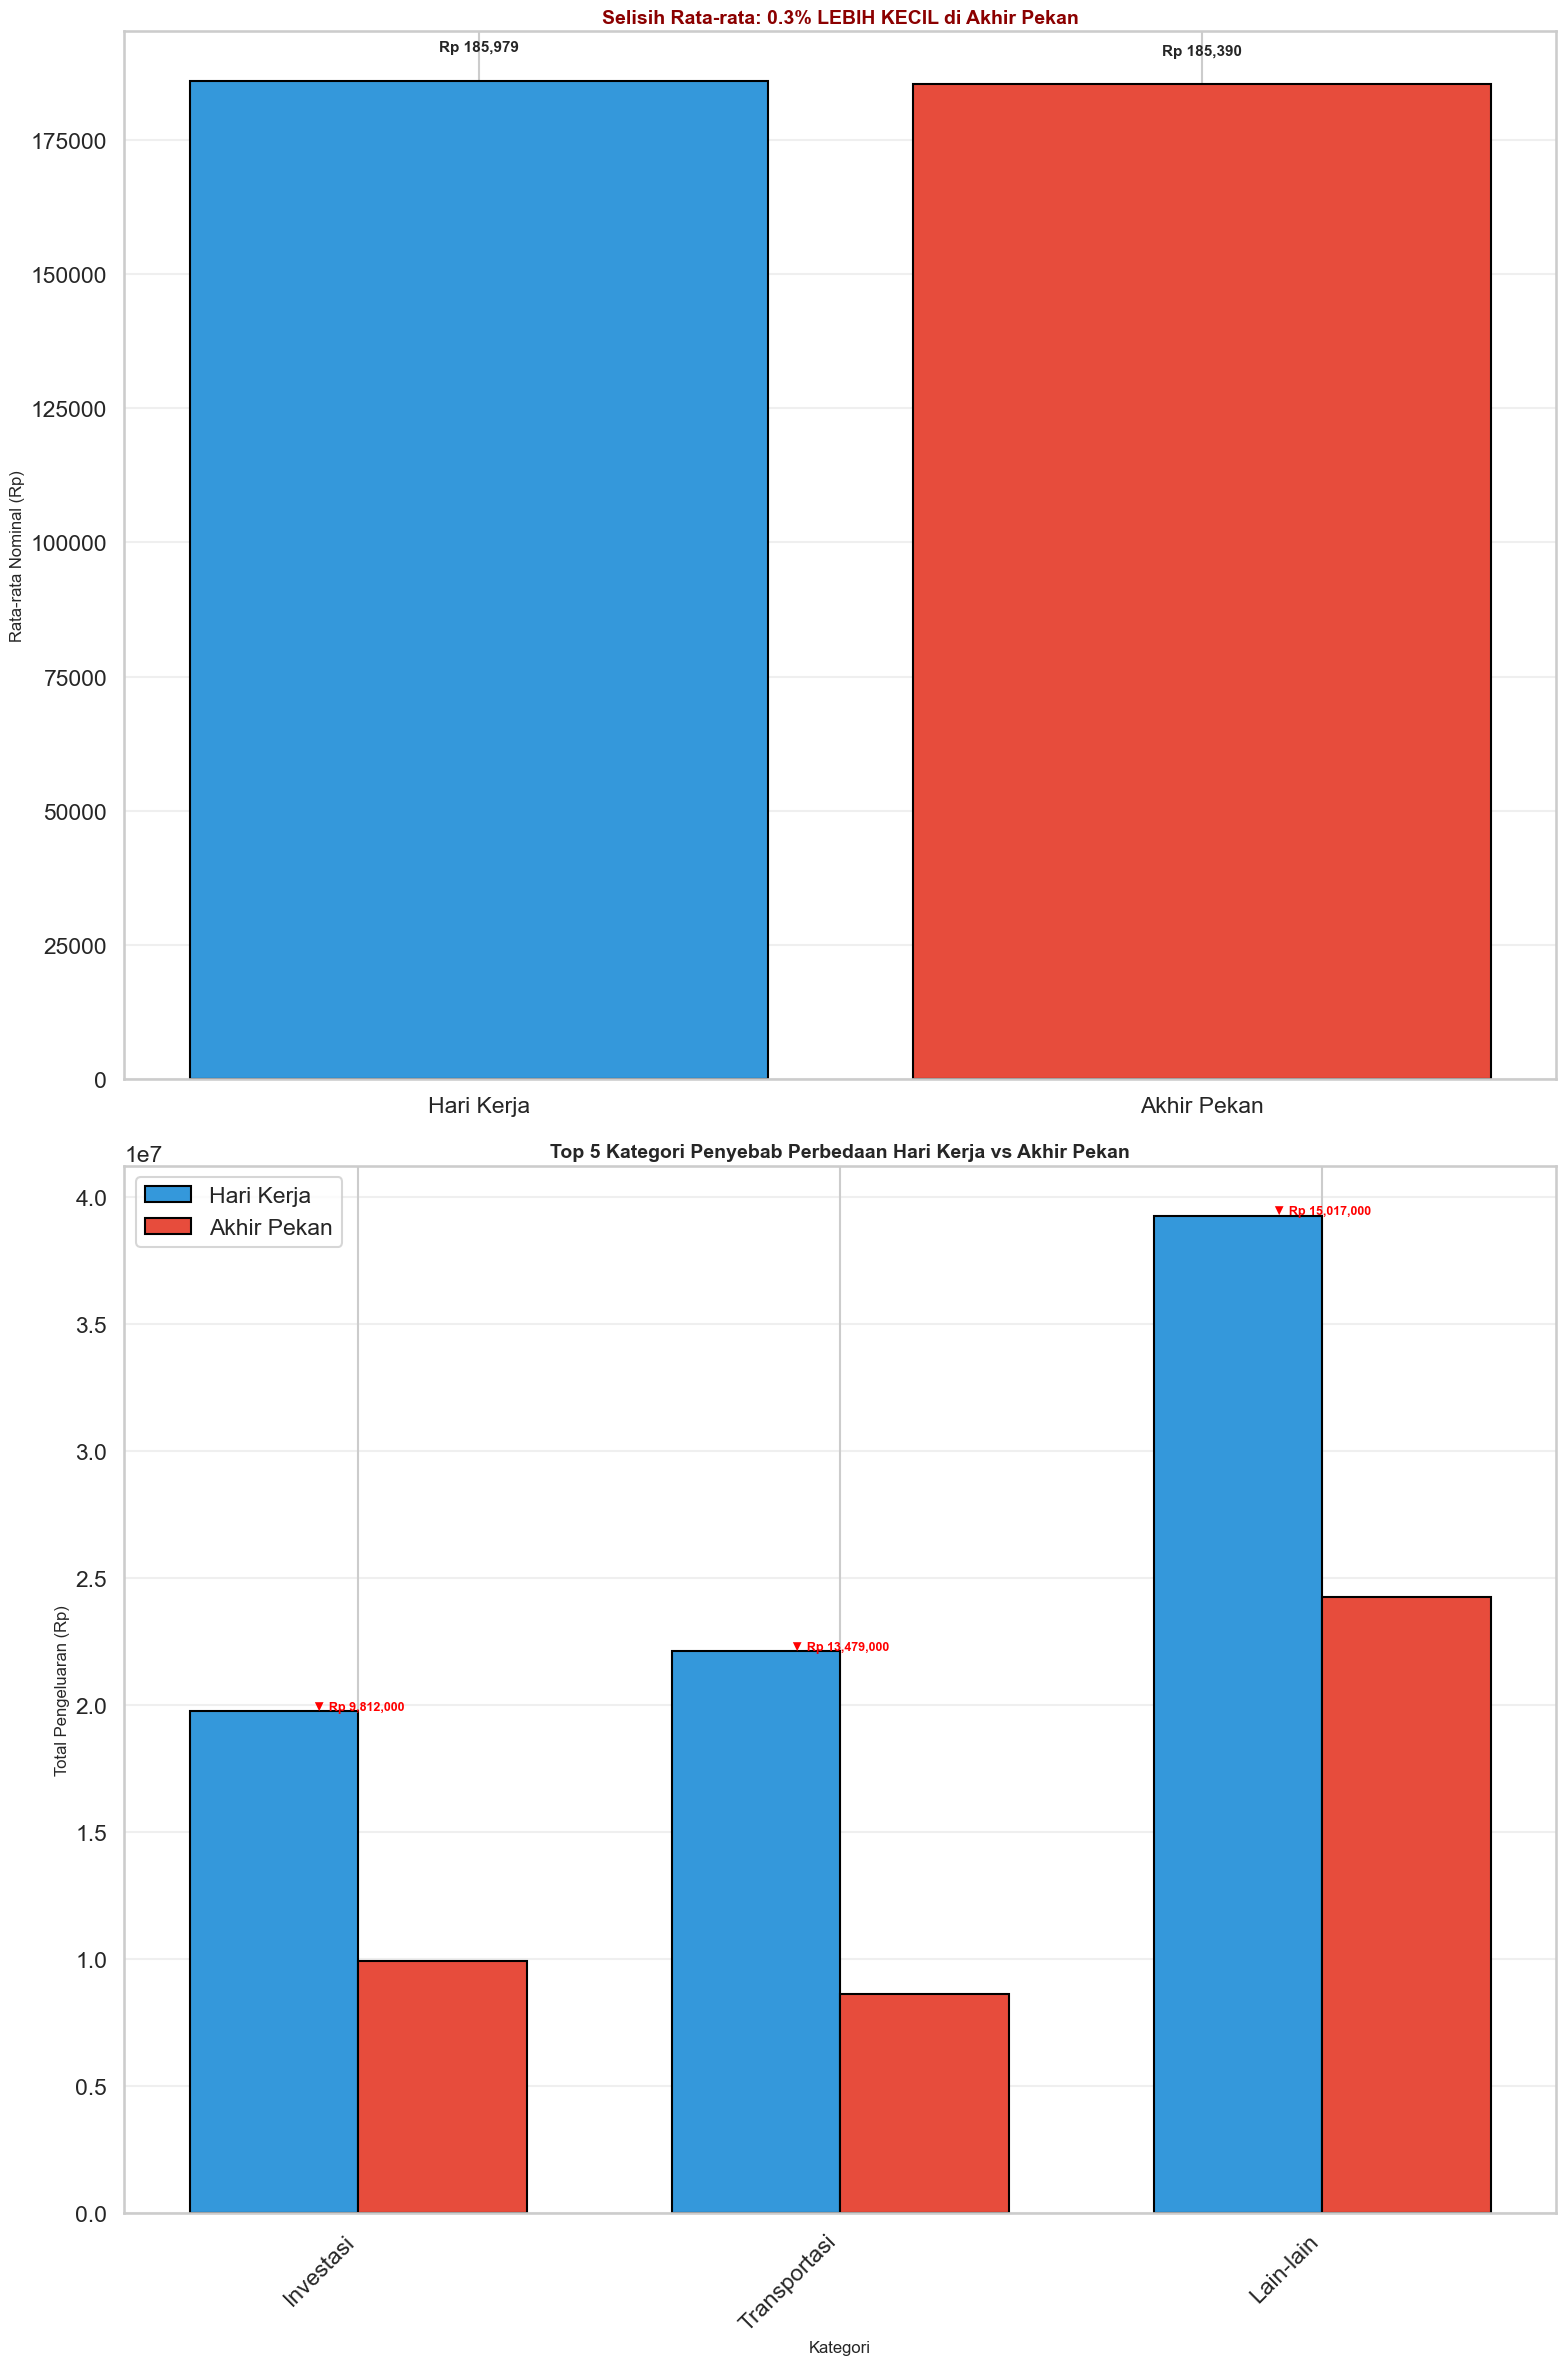

In [32]:

fig = plt.figure(figsize=(16, 24))

#Bar chart
ax2 = fig.add_subplot(2, 1, 1)

categories = ['Hari Kerja', 'Akhir Pekan']
values = [mean_per_hari.get('Hari Kerja', 0), mean_per_hari.get('Akhir Pekan', 0)]
colors_bar = ['#3498db', '#e74c3c']

bars = ax2.bar(categories, values, color=colors_bar, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'Rp {val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_title(f'Selisih Rata-rata: {persen_selisih:.1f}% {"LEBIH BESAR" if selisih > 0 else "LEBIH KECIL"} di Akhir Pekan', 
              fontsize=14, fontweight='bold', color='darkgreen' if selisih > 0 else 'darkred')
ax2.set_ylabel('Rata-rata Nominal (Rp)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Stacked Bar
ax3 = fig.add_subplot(2, 1, 2)

top5_kategori = top_penyebab.head(5)
top5_names = top5_kategori.index.tolist()

hari_kerja_vals = [top5_kategori.loc[cat, 'Hari Kerja'] for cat in top5_names]
akhir_pekan_vals = [top5_kategori.loc[cat, 'Akhir Pekan'] for cat in top5_names]

x = range(len(top5_names))
width = 0.35

bars1 = ax3.bar([i - width/2 for i in x], hari_kerja_vals, width, label='Hari Kerja', color='#3498db', edgecolor='black')
bars2 = ax3.bar([i + width/2 for i in x], akhir_pekan_vals, width, label='Akhir Pekan', color='#e74c3c', edgecolor='black')

for i, cat in enumerate(top5_names):
    selisih_cat = top5_kategori.loc[cat, 'selisih']
    tanda = '▲' if selisih_cat > 0 else '▼'
    warna = 'green' if selisih_cat > 0 else 'red'
    ax3.text(i, max(hari_kerja_vals[i], akhir_pekan_vals[i]) + 50000,
             f'{tanda} Rp {abs(selisih_cat):,.0f}', 
             ha='center', fontsize=9, color=warna, fontweight='bold')

ax3.set_title('Top 5 Kategori Penyebab Perbedaan Hari Kerja vs Akhir Pekan', fontsize=14, fontweight='bold')
ax3.set_xlabel('Kategori', fontsize=12)
ax3.set_ylabel('Total Pengeluaran (Rp)', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(top5_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Pertanyaan 3 - Berapa total kerugian finansial dari transaksi outlier (2 SD di atas rata-rata) dalam 1 tahun terakhir, dan berapa banyak yang sebenarnya bisa dicegah jika saya menerapkan aturan 'tunggu 3 hari sebelum belanja >500rb'?

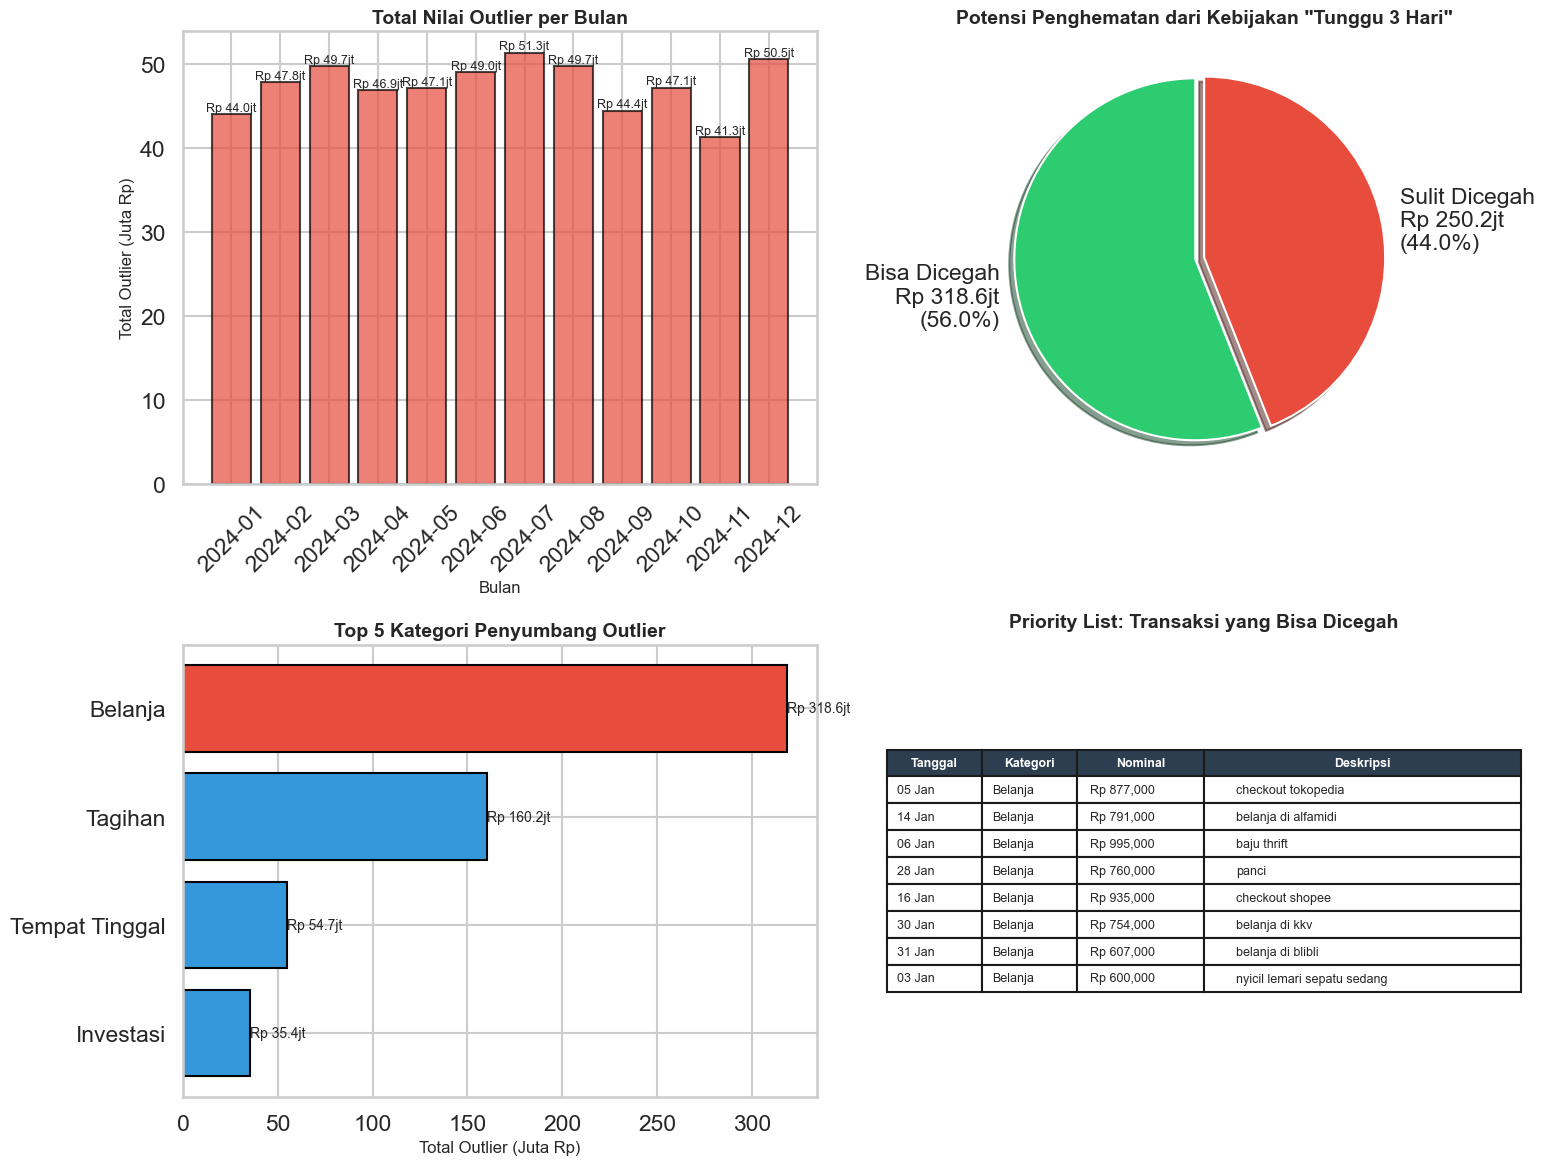

In [34]:
# pertanyaan 3 
outlier_list = []
outlier_details = []

for periode, group in df_1thn.groupby(df_1thn['tanggal'].dt.to_period('M')):
    mean = group['nominal'].mean()
    std = group['nominal'].std()
    batas_atas = mean + 2 * std
    
    outlier = group[group['nominal'] > batas_atas]
    
    for _, row in outlier.iterrows():
        outlier_details.append({
            'bulan': str(periode),
            'tanggal': row['tanggal'],
            'kategori': row['kategori'],
            'nominal': row['nominal'],
            'deskripsi': row['deskripsi_transaksi'],
            'batas_atas': batas_atas,
            'mean_bulan': mean
        })
    
    outlier_list.append({
        'bulan': str(periode),
        'total_transaksi': len(group),
        'jumlah_outlier': len(outlier),
        'total_outlier': outlier['nominal'].sum() if len(outlier) > 0 else 0,
        'batas_atas': batas_atas
    })

outlier_df = pd.DataFrame(outlier_details)
outlier_bulanan = pd.DataFrame(outlier_list)

total_outlier = outlier_df['nominal'].sum() if len(outlier_df) > 0 else 0
jumlah_outlier = len(outlier_df)


# Kriteria: kategori Belanja/Makanan dengan nominal > 500.000
bisa_dicegah = outlier_df[
    (outlier_df['kategori'].isin(['Belanja', 'Makanan'])) & 
    (outlier_df['nominal'] > 500_000)
].copy()

tidak_bisa_dicegah = outlier_df[~outlier_df.index.isin(bisa_dicegah.index)]

total_bisa_dicegah = bisa_dicegah['nominal'].sum() if len(bisa_dicegah) > 0 else 0
total_tidak_bisa = total_outlier - total_bisa_dicegah
persen_bisa_dicegah = (total_bisa_dicegah / total_outlier * 100) if total_outlier > 0 else 0

fig = plt.figure(figsize=(16, 12))

# Outlier per Bulan (Bar Chart)

ax1 = fig.add_subplot(2, 2, 1)

if len(outlier_bulanan) > 0:
    bars = ax1.bar(outlier_bulanan['bulan'], outlier_bulanan['total_outlier']/1_000_000, 
                   color='#e74c3c', edgecolor='black', alpha=0.7)
    ax1.set_title('Total Nilai Outlier per Bulan', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Bulan', fontsize=12)
    ax1.set_ylabel('Total Outlier (Juta Rp)', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    
    # Tambahkan nilai di atas bar
    for bar, val in zip(bars, outlier_bulanan['total_outlier']/1_000_000):
        if val > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'Rp {val:.1f}jt', ha='center', va='bottom', fontsize=9)
else:
    ax1.text(0.5, 0.5, 'Tidak ada outlier terdeteksi', ha='center', va='center', fontsize=14)
    ax1.set_title('Total Nilai Outlier per Bulan', fontsize=14, fontweight='bold')

# PLOT 2: Pie Chart (Bisa Dicegah vs Tidak)

ax2 = fig.add_subplot(2, 2, 2)

if total_outlier > 0:
    sizes = [total_bisa_dicegah, total_tidak_bisa]
    labels = [f'Bisa Dicegah\nRp {total_bisa_dicegah/1_000_000:.1f}jt\n({persen_bisa_dicegah:.1f}%)',
              f'Sulit Dicegah\nRp {total_tidak_bisa/1_000_000:.1f}jt\n({100-persen_bisa_dicegah:.1f}%)']
    colors_pie = ['#2ecc71', '#e74c3c']
    explode = (0.05, 0)
    
    ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='', startangle=90, explode=explode, shadow=True)
    ax2.set_title(f'Potensi Penghematan dari Kebijakan "Tunggu 3 Hari"', fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Tidak ada outlier', ha='center', va='center', fontsize=14)
    ax2.set_title('Potensi Penghematan', fontsize=14, fontweight='bold')

# Top Kategori Outlier (Bar Chart)

ax3 = fig.add_subplot(2, 2, 3)

if len(outlier_df) > 0:
    top_outlier_cat = outlier_df.groupby('kategori')['nominal'].sum().sort_values(ascending=False).head(5)
    colors_cat = ['#e74c3c' if cat in ['Belanja', 'Makanan'] else '#3498db' for cat in top_outlier_cat.index]
    
    bars = ax3.barh(range(len(top_outlier_cat)), top_outlier_cat.values/1_000_000, color=colors_cat, edgecolor='black')
    ax3.set_yticks(range(len(top_outlier_cat)))
    ax3.set_yticklabels(top_outlier_cat.index)
    ax3.set_xlabel('Total Outlier (Juta Rp)', fontsize=12)
    ax3.set_title('Top 5 Kategori Penyumbang Outlier', fontsize=14, fontweight='bold')
    ax3.invert_yaxis()
    
    # Tambahkan label nilai
    for bar, val in zip(bars, top_outlier_cat.values/1_000_000):
        ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'Rp {val:.1f}jt', va='center', fontsize=10)
else:
    ax3.text(0.5, 0.5, 'Tidak ada outlier', ha='center', va='center', fontsize=14)
    ax3.set_title('Top 5 Kategori Penyumbang Outlier', fontsize=14, fontweight='bold')


ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('tight')
ax4.axis('off')

if len(bisa_dicegah) > 0:
    # Siapkan data untuk tabel
    table_data = []
    for i, row in bisa_dicegah.head(8).iterrows():
        table_data.append([
            row['tanggal'].strftime('%d %b'),
            row['kategori'],
            f"Rp {row['nominal']:,.0f}",
            row['deskripsi'][:35] + ('...' if len(row['deskripsi']) > 35 else '')
        ])
    
    columns = ['Tanggal', 'Kategori', 'Nominal', 'Deskripsi']
    
    table = ax4.table(cellText=table_data, colLabels=columns, loc='center',
                      cellLoc='left', colWidths=[0.15, 0.15, 0.2, 0.5])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    
    # Warna header
    for j, col in enumerate(columns):
        table[(0, j)].set_facecolor('#2c3e50')
        table[(0, j)].set_text_props(weight='bold', color='white')
    
    ax4.set_title('Priority List: Transaksi yang Bisa Dicegah', fontsize=14, fontweight='bold', y=1.02)
else:
    ax4.text(0.5, 0.5, 'Tidak ada transaksi yang memenuhi kriteria\n(Belanja/Makanan > Rp500rb)', 
             ha='center', va='center', fontsize=12, transform=ax4.transAxes)
    ax4.set_title('Priority List', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()